In [ ]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os
import tikzplotlib

ENTITY = "alessandro-montenegro-polimi"
PROJECT = "rt-ppo-hopper-v2"

api = wandb.Api()
runs = list(api.runs(f"{ENTITY}/{PROJECT}"))

print(f"Total runs trovate nel progetto: {len(runs)}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/ricca/.netrc.


Total runs trovate nel progetto: 403


In [3]:
all_groups = sorted({run.group for run in runs if run.group is not None})
print(f"Numero group trovati: {len(all_groups)}\n")

for g in all_groups:
    print(g)


all_tags = sorted({
    tag
    for run in runs
    for tag in (run.tags or [])
})

print("\n")
print(f"Numero tag trovati: {len(all_tags)}\n")

for tag in all_tags:
    print(tag)

Numero group trovati: 27

PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=512 n_updates=1 kl_target=None
PPO 2x256=512 epochs=4 n_minibatch=2 batch_size=256 n_updates=8 kl_target=None
PPO 2x256=512 epochs=8 n_minibatch=1 batch_size=512 n_updates=8 kl_target=None
RT-PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=1024 n_updates=1 kl_target=None w=2 opc=True weight_type=bh kl_target=None
RT-PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=1024 n_updates=1 kl_target=None w=2 opc=True weight_type=naive kl_target=None
RT-PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=2048 n_updates=1 kl_target=None w=4 opc=True weight_type=bh kl_target=None
RT-PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=2048 n_updates=1 kl_target=None w=4 opc=True weight_type=naive kl_target=None
RT-PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=4096 n_updates=1 kl_target=None w=8 opc=True weight_type=bh kl_target=None
RT-PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=4096 n_updates=1 kl_target=None w=8 opc=True weigh

In [62]:
METRIC = "rollout/ep_rew_mean"
X_AXIS = "global_step"
SMOOTH = 0.0
# Subsampling: numero di punti da mantenere per run (None = no subsampling)
SUBSAMPLE_POINTS = 1000  # es: 500, 1000, None

# scegli se filtrare le runs per tags o per nome del gruppo
REQUIRED_TAGS = ["B_fixed","K_fixed"]

SELECTED_GROUPS = []


# ============================================================
# RUNS FILTER
# ============================================================

groups = defaultdict(list)

for run in runs:
    group = run.group
    tags = run.tags or []

    if SELECTED_GROUPS and group not in SELECTED_GROUPS:
        continue

    if not all(tag in tags for tag in REQUIRED_TAGS):
        continue

    key = group if group is not None else "NO_GROUP"
    groups[key].append(run)

print("Run valide dopo il filtro:\n")
for group_name, group_runs in groups.items():
    print(f"{group_name}: {len(group_runs)} runs")
    #for run in group_runs:
        #print(f"  - {run.name} | state={run.state} | id={run.id}")
    print()


Run valide dopo il filtro:

PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=512 n_updates=1 kl_target=None: 20 runs

RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=bh kl_target=None: 10 runs

RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=naive kl_target=None: 10 runs

RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=bh kl_target=None: 10 runs

RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=naive kl_target=None: 10 runs

RT-PPO 2x256=512 epochs=1 n_minibatch=8 batch_size=512 n_updates=8 kl_target=None w=8 opc=True weight_type=bh kl_target=None: 10 runs

RT-PPO 2x256=512 epochs=1 n_minibatch=8 batch_size=512 n_updates=8 kl_target=None w=8 opc=True weight_type=naive kl_target=None: 10 runs



In [63]:
# ============================================================
# DOWNLOAD ALL HISTORIES FIRST
# ============================================================

def smooth(y, weight):
    if weight <= 0:
        return y
    out = [y[0]]
    for v in y[1:]:
        out.append(out[-1] * weight + (1 - weight) * v)
    return np.array(out)


def subsample(x, y, n_points):
    """
    Sottocampiona i dati mantenendo n_points punti distribuiti uniformemente.
    Preserva sempre il primo e l'ultimo punto.
    """
    if n_points is None or len(y) <= n_points:
        return x, y
    
    indices = np.linspace(0, len(y) - 1, n_points, dtype=int)
    return x[indices], y[indices]

all_histories = {}

for group_name, group_runs in groups.items():
    all_histories[group_name] = []

    for run in group_runs:
        history = run.history(keys=[X_AXIS, METRIC], pandas=True)

        if history.empty:
            continue

        x = history[X_AXIS].to_numpy()
        y = history[METRIC].to_numpy()

        mask = ~np.isnan(x) & ~np.isnan(y)
        x = x[mask]
        y = y[mask]

        if len(y) == 0:
            continue

        y = smooth(y, SMOOTH)
        x, y = subsample(x, y, SUBSAMPLE_POINTS)

        all_histories[group_name].append((x, y))

print("Download histories completato.\n")
# for group_name, items in all_histories.items():
#     print(f"{group_name}: {len(items)} histories valide")

Download histories completato.

PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=512 n_updates=1 kl_target=None: 20 histories valide
RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=bh kl_target=None: 10 histories valide
RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=naive kl_target=None: 10 histories valide
RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=bh kl_target=None: 10 histories valide
RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=naive kl_target=None: 10 histories valide
RT-PPO 2x256=512 epochs=1 n_minibatch=8 batch_size=512 n_updates=8 kl_target=None w=8 opc=True weight_type=bh kl_target=None: 10 histories valide
RT-PPO 2x256=512 epochs=1 n_minibatch=8 batch_size=512 n_updates=8 kl_target=None w=8 opc=True weight_type=naive kl_target=None: 10 

In [67]:
# ============================================================
# AUTO-GENERATED STYLE DICT FOR LEGEND LABELS AND COLORS
# Copia l'output qui sotto nello snippet successivo e modificalo a mano.
# label = nome da mostrare in legenda
# color = colore matplotlib, oppure None per usare il default
# ============================================================

default_colors = [
    "#648FFF",  # blu
    "#785EF0",  # viola
    "#DC267F",  # magenta
    "#FE6100",  # arancione
    "#FFB000",  # giallo
    "#009E73",  # verde
    "#56B4E9",  # azzurro
    "#000000",  # nero
]

print("\n# Copia questo dizionario nello snippet sotto e personalizzalo:\n")
print("GROUP_STYLES = {")

group_names = sorted(groups.keys())

for i, group_name in enumerate(group_names):
    safe_group_name = repr(group_name)
    color = default_colors[i % len(default_colors)]

    # label corta di default
    if group_name.startswith("PPO"):
        short_label = "PPO"
    elif "weight_type=bh" in group_name:
        w = group_name.split("w=")[1].split()[0]
        short_label = rf"RT-PPO-BH: $\omega = {w}$"
    elif "weight_type=naive" in group_name:
        w = group_name.split("w=")[1].split()[0]
        short_label = rf"RT-PPO-N: $\omega = {w}$"
    else:
        short_label = group_name

    print(f"    {safe_group_name}: {{")
    print(f"        'label': {repr(short_label)},")
    print(f"        'color': '{color}',")
    print("    },")

    if i < len(group_names) - 1:
        print()

print("}")


# copialo qua sotto
GROUP_STYLES = {
    'PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=512 n_updates=1 kl_target=None': {
        'label': 'PPO',
        'color': '#648FFF',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=bh kl_target=None': {
        'label': 'RT-PPO-BH: $\\omega=2$',
        'color': '#785EF0',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=naive kl_target=None': {
        'label': 'RT-PPO-N: $\\omega=2$',
        'color': '#DC267F',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=bh kl_target=None': {
        'label': 'RT-PPO-BH: $\\omega=4$',
        'color': '#FE6100',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=naive kl_target=None': {
        'label': 'RT-PPO-N: $\\omega=4$',
        'color': '#FFB000',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=8 batch_size=512 n_updates=8 kl_target=None w=8 opc=True weight_type=bh kl_target=None': {
        'label': 'RT-PPO-BH: $\\omega=8$',
        'color': '#009E73',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=8 batch_size=512 n_updates=8 kl_target=None w=8 opc=True weight_type=naive kl_target=None': {
        'label': 'RT-PPO-N: $\\omega=8$',
        'color': '#56B4E9',
    },
}


# Copia questo dizionario nello snippet sotto e personalizzalo:

GROUP_STYLES = {
    'PPO 2x256=512 epochs=1 n_minibatch=1 batch_size=512 n_updates=1 kl_target=None': {
        'label': 'PPO',
        'color': '#648FFF',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=bh kl_target=None': {
        'label': 'RT-PPO-BH: $\\omega = 2$',
        'color': '#785EF0',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=2 batch_size=512 n_updates=2 kl_target=None w=2 opc=True weight_type=naive kl_target=None': {
        'label': 'RT-PPO-N: $\\omega = 2$',
        'color': '#DC267F',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=bh kl_target=None': {
        'label': 'RT-PPO-BH: $\\omega = 4$',
        'color': '#FE6100',
    },

    'RT-PPO 2x256=512 epochs=1 n_minibatch=4 batch_size=512 n_updates=4 kl_target=None w=4 opc=True weight_type=naive kl_t

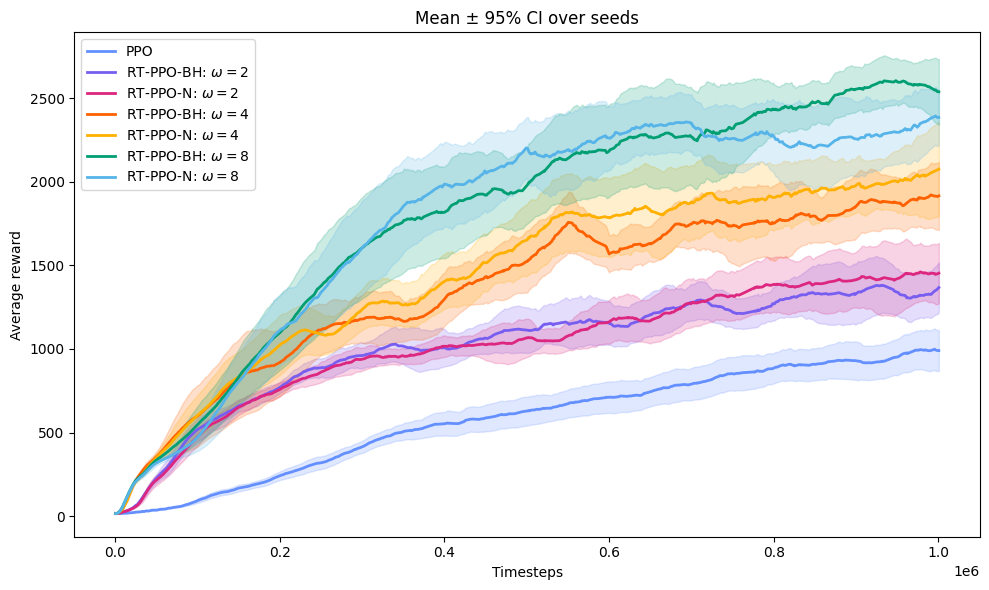

In [66]:
# ============================================================
# OPTIONAL: manual style config
# ============================================================
# Esempio:
# GROUP_STYLES = {
#     "group_1": {"label": "PPO baseline", "color": "#1f77b4"},
#     "group_2": {"label": "RT-PPO w=4", "color": "#ff7f0e"},
# }

if "GROUP_STYLES" not in globals():
    GROUP_STYLES = {}


# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(10, 6))

for group_name, group_histories in all_histories.items():
    curves = []
    x_ref = None
    min_len = np.inf

    for x, y in group_histories:
        if len(y) == 0:
            continue

        if x_ref is None:
            x_ref = x

        min_len = min(min_len, len(y))
        curves.append(y)

    if len(curves) < 2:
        print(f"Skip {group_name}: meno di 2 run valide")
        continue

    curves = np.array([c[:min_len] for c in curves])
    x = x_ref[:min_len]

    mean = curves.mean(axis=0)
    std = curves.std(axis=0)
    ci = 1.96 * std / np.sqrt(len(curves))

    style = GROUP_STYLES.get(group_name, {})
    legend_label = style.get("label", group_name)
    color = style.get("color", None)

    plt.plot(
        x,
        mean,
        label=legend_label,
        color=color,
        linewidth=2,
    )

    plt.fill_between(
        x,
        mean - ci,
        mean + ci,
        alpha=0.2,
        color=color,
    )

plt.xlabel("Timesteps")
plt.ylabel("Average reward")
plt.title("Mean ± 95% CI over seeds")
#plt.grid(True)

plt.legend(
    loc="best",
)

plt.tight_layout()
plt.show()

In [ ]:
PLOTS_DIR = "plots"
PLOT_NAME = "test_01"


def get_unique_base_path(folder, base_name):
    """
    Restituisce un nome base unico senza estensione:
    plots/name
    plots/name_1
    plots/name_2
    ...
    """
    base_path = os.path.join(folder, base_name)

    if not any(
        os.path.exists(f"{base_path}.{ext}") for ext in ["pdf", "png", "tex"]
    ):
        return base_path

    i = 1
    while any(
        os.path.exists(f"{base_path}_{i}.{ext}") for ext in ["pdf", "png", "tex"]
    ):
        i += 1

    return f"{base_path}_{i}"


# ============================================================
# SAVE WITHOUT OVERWRITING
# ============================================================
os.makedirs(PLOTS_DIR, exist_ok=True)

base_path = get_unique_base_path(PLOTS_DIR, PLOT_NAME)

pdf_path = f"{base_path}.pdf"
png_path = f"{base_path}.png"
tex_path = f"{base_path}.tex"

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
tikzplotlib.save(tex_path)

print("Plot salvato in:")
print(f"  PDF: {pdf_path}")
print(f"  PNG: {png_path}")
print(f"  TEX: {tex_path}")